In [1]:
import pandas as pd

df = pd.read_csv("data/Assignment_2/binary_classification/IMDB Dataset.csv")
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [2]:
df.shape


(50000, 2)

In [3]:
import re


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\<.*?\>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\n", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = f"<START> {text}"

    return text


df["review"] = df["review"].apply(clean_text)
df["sentiment"] = df["sentiment"].apply(lambda x: 1 if x == "positive" else 0)
df.head()


,review,sentiment
0,<START> one of the other reviewers has mention...,1
1,<START> a wonderful little production. the fil...,1
2,<START> i thought this was a wonderful way to ...,1
3,<START> basically there's a family where a lit...,0
4,"<START> petter mattei's ""love in the time of m...",1


In [4]:
from sklearn.model_selection import train_test_split

X, y = df["review"], df["sentiment"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
X_train[:3], y_train[:3]


(40000,) (40000,) (10000,) (10000,)


(39087    <START> that's what i kept asking myself durin...
 30893    <START> i did not watch the entire movie. i co...
 45278    <START> a touching love story reminiscent of ...
 Name: review, dtype: object,
 39087    0
 30893    0
 45278    1
 Name: sentiment, dtype: int64)

In [5]:
from tensorflow.keras.preprocessing.text import Tokenizer

MAX_VOCAB = 10000
MAX_LEN = 500

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

X_train_sequences = tokenizer.texts_to_sequences(X_train)
# X_train_sequences is a list[list] of dim 40000*variable


2026-05-12 16:52:59.489331: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-12 16:52:59.489906: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-12 16:52:59.493315: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-12 16:52:59.504527: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778584979.522933   42471 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778584979.52

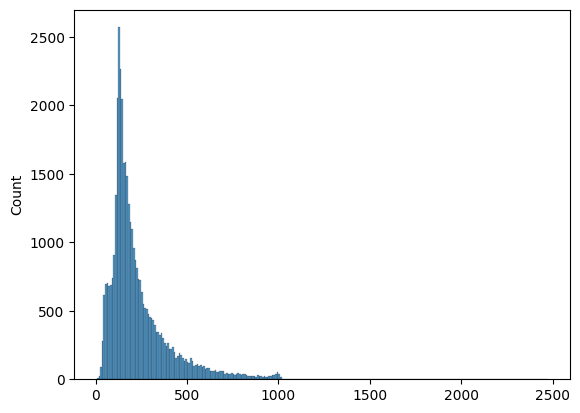

distribution of 40000 reviews


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

review_lengths = [len(X_train_sequences[i]) for i in range(len(X_train_sequences))]

sns.histplot(review_lengths)
plt.show()

print(f"distribution of {len(X_train)} reviews")


In [7]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_pad = pad_sequences(X_train_sequences, maxlen=MAX_LEN)

print(X_train_pad.shape)


(40000, 500)


In [8]:
print(X_train_pad[0])


[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0   27  198   49
   10  801 2161  534  303    2  108 1907 2038 4324 6548    3  813 4843
   12    1    2    1  228    2 6187   80  782   54   53   22  102    5
    2   28 2009  103   37   25   35  120 1130   12    9    7 2365 1190
    6  454   49  552    6   93   34   23   40  916  400    1   15    2
  167    6 2994   24    1 4360   20    4 2945   12   46   76  222   74
  127    8   82 3153  196   20  240    3    2  446   10  206 4949  145
   21   64   28   15    1   75  366  303    4   19   18    9  206   26
  308 

In [9]:
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding
from tensorflow.keras.models import Sequential

EMBEDDING_DIM = 128

model = Sequential(
    [
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(24, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid"),
    ],
)

model.compile(loss="binary_crossentropy", metrics=["accuracy"], optimizer="adam")

model.summary()


/home/sudarshan/projects/learnings/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-05-12 16:54:28.845612: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
)


Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 188s 186ms/step - accuracy: 0.8087 - loss: 0.4199 - val_accuracy: 0.8668 - val_loss: 0.3176
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 186s 186ms/step - accuracy: 0.9005 - loss: 0.2622 - val_accuracy: 0.8679 - val_loss: 0.3432
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 185s 185ms/step - accuracy: 0.9206 - loss: 0.2108 - val_accuracy: 0.8366 - val_loss: 0.3803
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 187s 187ms/step - accuracy: 0.9486 - loss: 0.1471 - val_accuracy: 0.8900 - val_loss: 0.3323
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 188s 188ms/step - accuracy: 0.9558 - loss: 0.1257 - val_accuracy: 0.8727 - val_loss: 0.3661


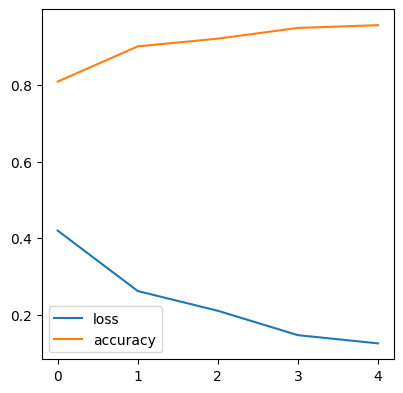

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["accuracy"], label="accuracy")
plt.legend()


In [12]:
X_test_sequences = tokenizer.texts_to_sequences(X_test)
X_test_pad = pad_sequences(X_test_sequences)


In [13]:
test_loss, test_acc = model.evaluate(X_test_pad, y_test)
print(test_loss, test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 186ms/step - accuracy: 0.8754 - loss: 0.3614
0.3614174425601959 0.8754000067710876


In [14]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test_pad)
y_pred = (y_pred > 0.5).astype(int)
print(classification_report(y_test, y_pred, target_names=["Negative", "Postive"]))


313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 187ms/step
              precision    recall  f1-score   support

    Negative       0.88      0.87      0.87      4961
     Postive       0.87      0.88      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



<Axes: >

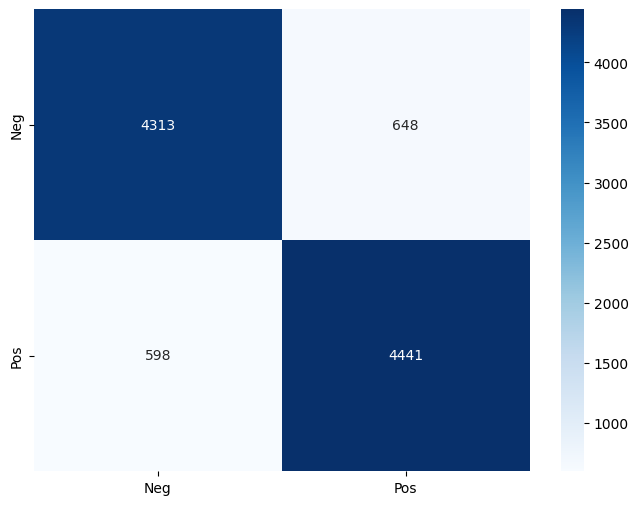

In [15]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Neg", "Pos"],
    yticklabels=["Neg", "Pos"],
)
